#  Assignment 1: Basic image processing and histograms

### Exercise 1: Basic image processing

In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

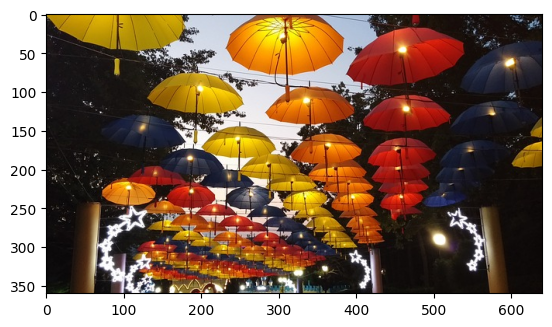

In [3]:
umbrellas = cv2.imread('./images/umbrellas.jpg')
umbrellas = cv2.cvtColor(umbrellas, cv2.COLOR_BGR2RGB)
plt.imshow(umbrellas)

In [4]:
height, width, channels = umbrellas.shape
print(height, width, channels)

umbrellas.dtype

360 640 3


dtype('uint8')

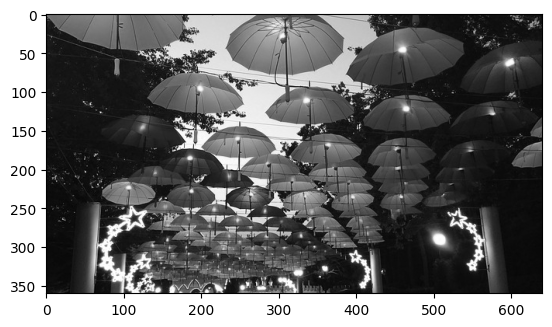

In [5]:
umbrellas_gray  = (np.float64(umbrellas[:,:,0]) + np.float64(umbrellas[:,:,1]) + np.float64(umbrellas[:,:,2])) / 3
plt.imshow(umbrellas_gray, cmap='gray')
plt.show()

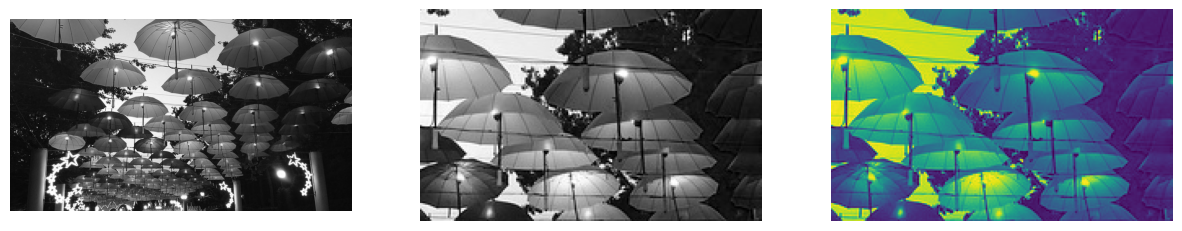

In [6]:
plt.figure(figsize=(15, 3))
cutout = umbrellas[130:260, 240:450, 1]

plt.subplot(1, 3, 1)
plt.imshow(umbrellas_gray, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cutout, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cutout, cmap='viridis')
plt.axis('off')
plt.show()

 Why would you use different color maps?
So we can highlight different features of an image.

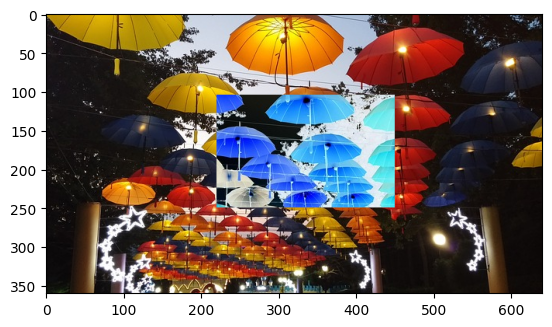

In [7]:
img_cutout = umbrellas.copy()
img_part = img_cutout[105:250, 220:450, :]
img_invert = 255 - img_part
img_cutout[105:250, 220:450, :] = img_invert
plt.imshow(img_cutout)

(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

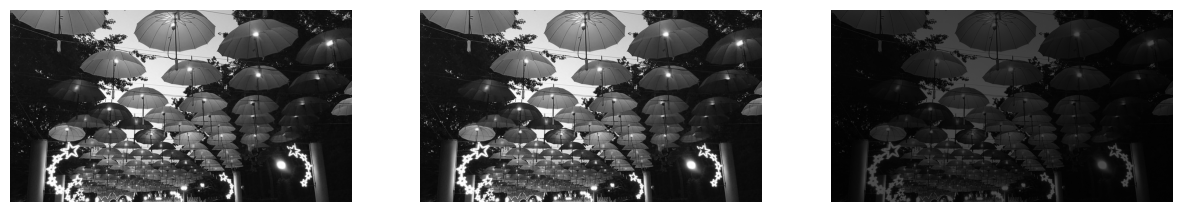

In [8]:
plt.figure(figsize=(15, 3))
umbrellas_rescaled = umbrellas_gray.copy() / 255

umbrellas_rescaled = umbrellas_rescaled * 0.3 #every pixel is multiplied by 0.3 so the max 1 is now 0.3
plt.subplot(1,3,1)
plt.imshow(umbrellas_gray, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(umbrellas_rescaled, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(umbrellas_rescaled, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

Pyplot tries to maximize the contrast in displayed images by checking their values and scaling
them. To avoid this, we need to set the maximum expected value when using plt.imshow(), like plt.imshow(I, vmin=0, vmax=1).

### Exercise 2: Thresholding and histograms

(np.float64(-0.5), np.float64(639.5), np.float64(491.5), np.float64(-0.5))

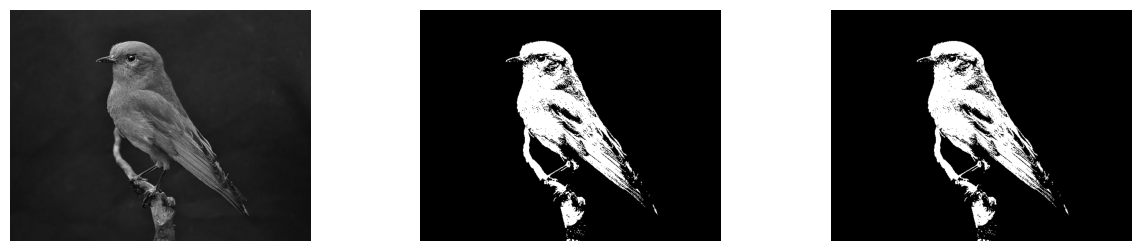

In [9]:
plt.figure(figsize=(15, 3))
bird = cv2.imread('./images/bird.jpg')
bird = cv2.cvtColor(bird, cv2.COLOR_BGR2RGB)
bird_gray = cv2.cvtColor(bird, cv2.COLOR_BGR2GRAY)

plt.subplot(1,3,1)
plt.imshow(bird_gray, cmap='gray')
plt.axis('off')

bird_mask = bird_gray.copy() / 255
threshold = 0.3
bird_mask[bird_mask < threshold] = 0
bird_mask[bird_mask >= threshold] = 1

plt.subplot(1,3,2)
plt.imshow(bird_mask, cmap='gray')
plt.axis('off')

bird_mask2 = np.where(bird_mask < threshold, 0, 1)
plt.subplot(1,3,3)
plt.imshow(bird_mask2, cmap='gray')
plt.axis('off')


In [10]:
def myhist(I_gray, n_bins):
    I_gray = I_gray.reshape(-1)
    bin_size = 1 / n_bins
    H = np.zeros(n_bins)
    max_value = I_gray.max()

    for pix in I_gray:
        for i in range(1, n_bins):
            if pix < (i * bin_size):
                H[i - 1] += 1
                break
            elif pix == max_value:
                H[-1] += 1
                break

    H = H / sum(H)
    return H

<BarContainer object of 20 artists>

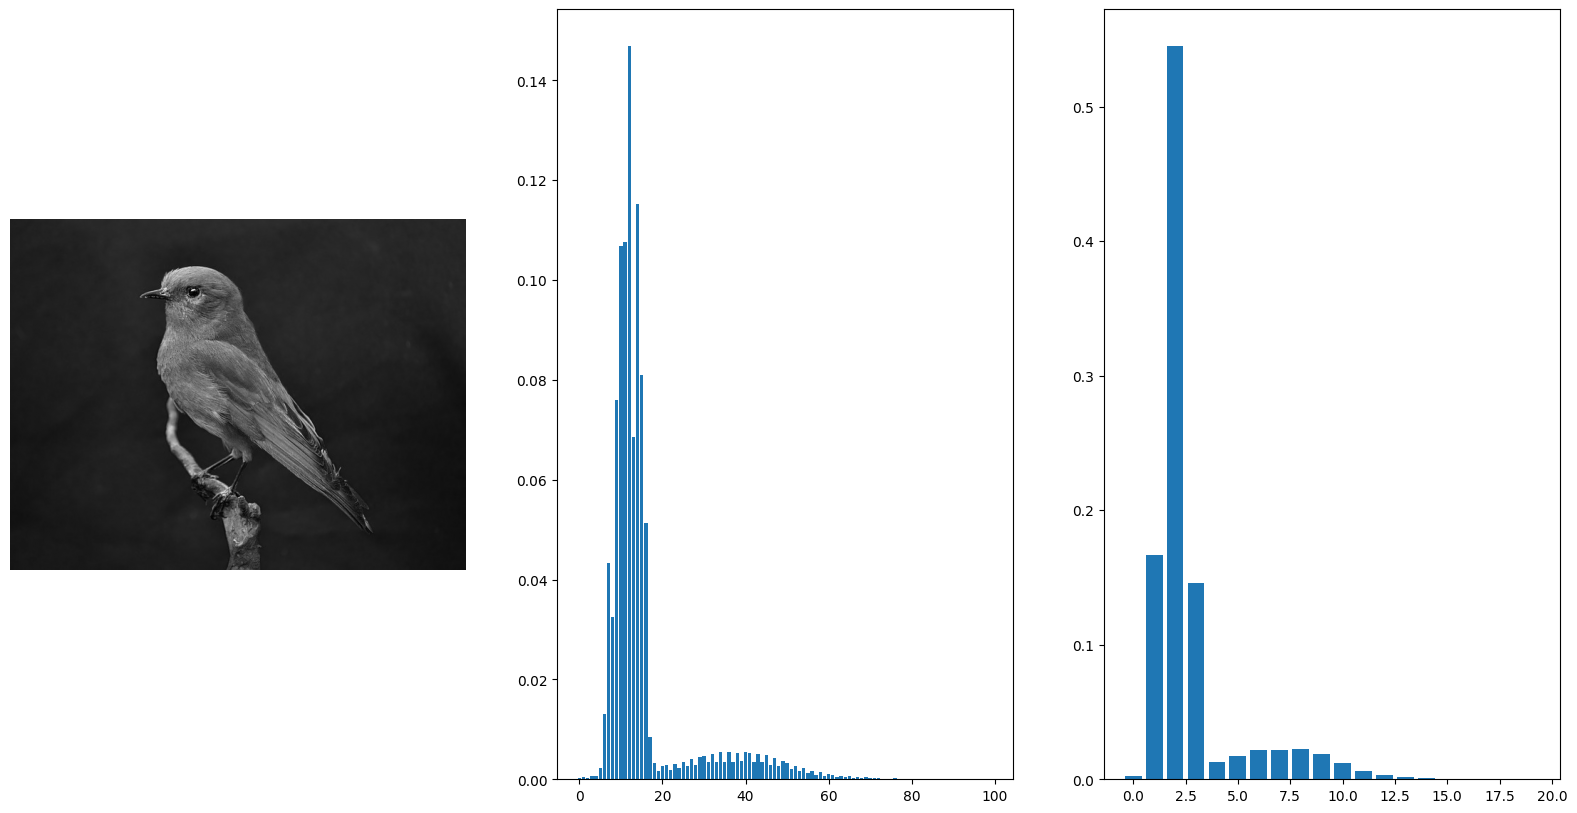

In [11]:
bird = cv2.imread('./images/bird.jpg')
bird = cv2.cvtColor(bird, cv2.COLOR_BGR2RGB)
bird_gray = cv2.cvtColor(bird, cv2.COLOR_BGR2GRAY) / 255
bird_gray = bird_gray.astype(np.float32)
# print(np.max(bird_gray), np.min(bird_gray))

plt.figure(figsize=(20,10))
plt.subplot(1,3,1)
plt.imshow(bird_gray, cmap='gray')
plt.axis('off')

n_bins = 100
H = myhist(bird_gray, n_bins)
plt.subplot(1,3,2)
plt.bar(np.arange(n_bins), H)

n_bins = 20
H = myhist(bird_gray, n_bins)
plt.subplot(1,3,3)
plt.bar(np.arange(n_bins), H)


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

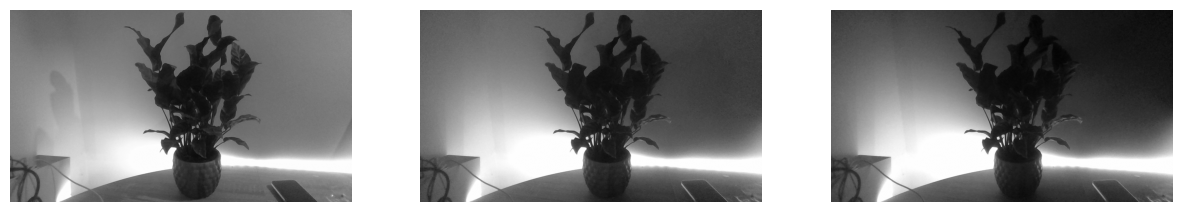

In [12]:
flower1 = cv2.imread('./images/flower1.jpg')
flower1 = cv2.cvtColor(flower1, cv2.COLOR_BGR2GRAY) / 255
flower2 = cv2.imread('./images/flower2.jpg')
flower2 = cv2.cvtColor(flower2, cv2.COLOR_BGR2GRAY) / 255
flower3 = cv2.imread('./images/flower3.jpg')
flower3 = cv2.cvtColor(flower3, cv2.COLOR_BGR2GRAY) / 255
plt.figure(figsize=(15,10))
plt.subplot(1,3,1)
plt.imshow(flower1, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(flower2, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(flower3, cmap='gray')
plt.axis('off')


<BarContainer object of 100 artists>

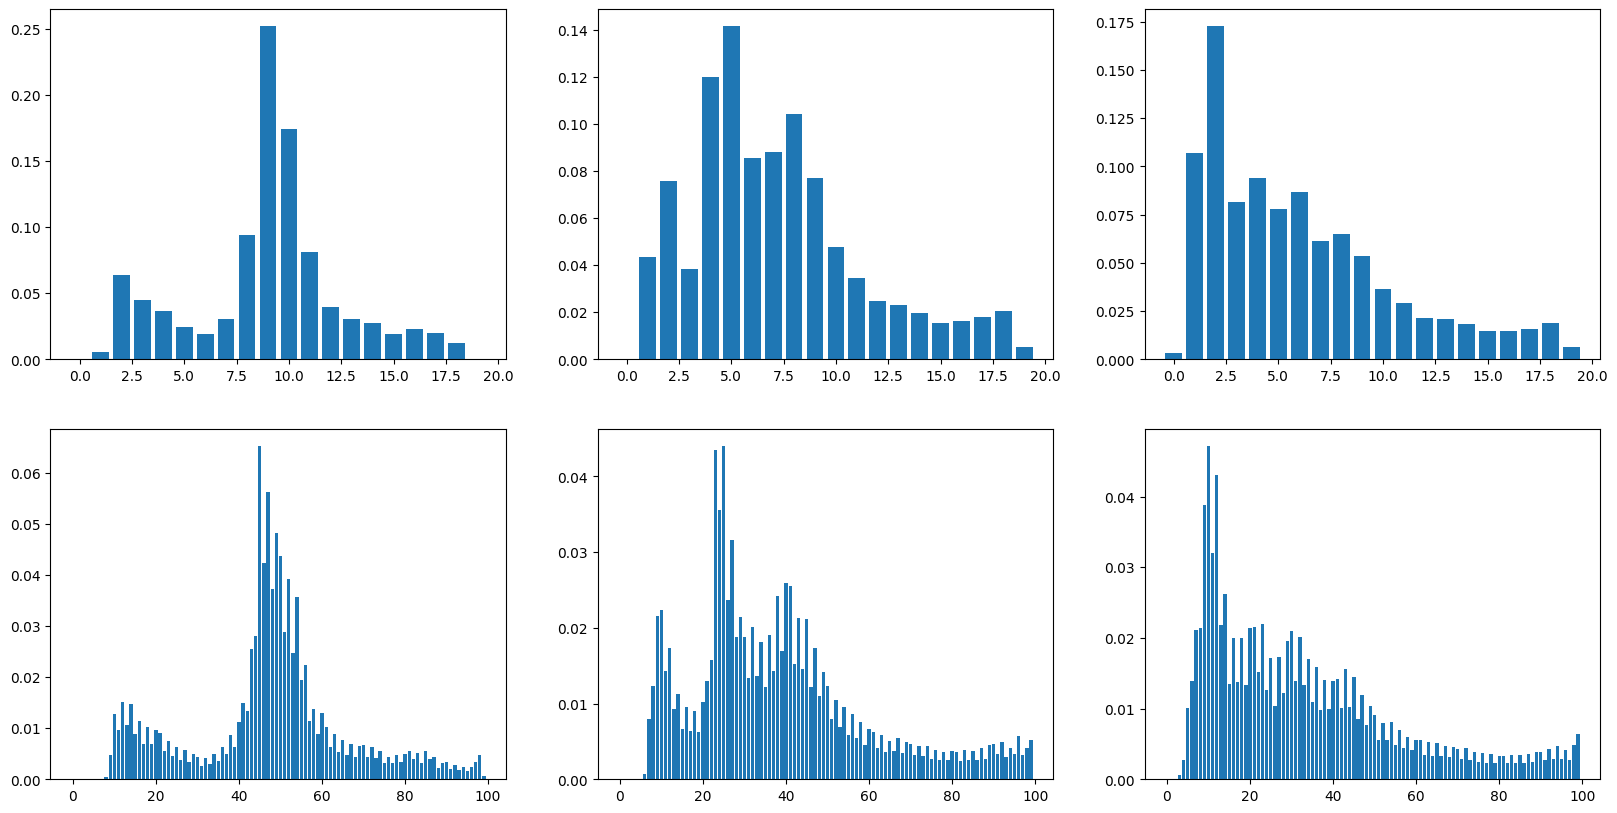

In [13]:

plt.figure(figsize=(20,10))
hist1 = myhist(flower1, 20)
plt.subplot(2,3,1)
plt.bar(np.arange(20), hist1)

hist2 = myhist(flower2, 20)
plt.subplot(2,3,2)
plt.bar(np.arange(20), hist2)

hist3 = myhist(flower3, 20)
plt.subplot(2,3,3)
plt.bar(np.arange(20), hist3)

hist1 = myhist(flower1, 100)
plt.subplot(2,3,4)
plt.bar(np.arange(100), hist1)

hist2 = myhist(flower2, 100)
plt.subplot(2,3,5)
plt.bar(np.arange(100), hist2)

hist3 = myhist(flower3, 100)
plt.subplot(2,3,6)
plt.bar(np.arange(100), hist3)



#### Interpretation of the results

With both lights on, the image appears brighter. We can see that in the histogram by a higher concentration of pixels with larger intensity values. After turning off one light source, we can see a shift toward the left - so the lower intensity values. And finally after turning off both lights the image became much darker and the histogram is concentrated on the left side indicating more dark pixels.

In [14]:
def otsu(I_gray):
    n_bins = 100
    H = myhist(I_gray, n_bins)
    max_variance = 0
    optimal_threshold = 0
    bins = list(range(n_bins))
    min_gray = np.min(I_gray)
    max_gray = np.max(I_gray)
    bin_range = (max_gray - min_gray) / n_bins

    for thresh in range(1, n_bins):
        groupB = sum(H[0:thresh])
        groupF = sum(H[thresh:n_bins])

        meanB = sum(H[i] * bins[i] for i in range(thresh)) / groupB
        meanF = sum(H[i] * bins[i] for i in range(thresh, n_bins)) / groupF

        variance = groupB * groupF * (meanB - meanF) ** 2

        if variance > max_variance:
            max_variance = variance
            optimal_threshold = thresh


    optimal_threshold = optimal_threshold * bin_range
    return optimal_threshold

In [15]:
def otsu_mask(I_gray, threshold):
    otsu_mask = np.where(I_gray < threshold, 0, 1)
    return otsu_mask


0.27780393


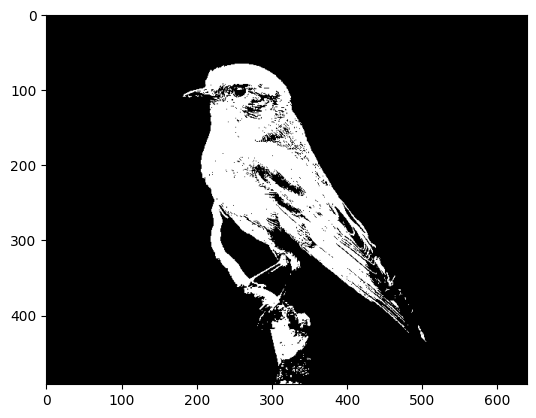

In [16]:
bird_thresh = otsu(bird_gray)
print(bird_thresh)
bird_otsu = otsu_mask(bird_gray, bird_thresh)
plt.imshow(bird_otsu, cmap='gray')

## Exercise 3: Morphological operations and regions

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

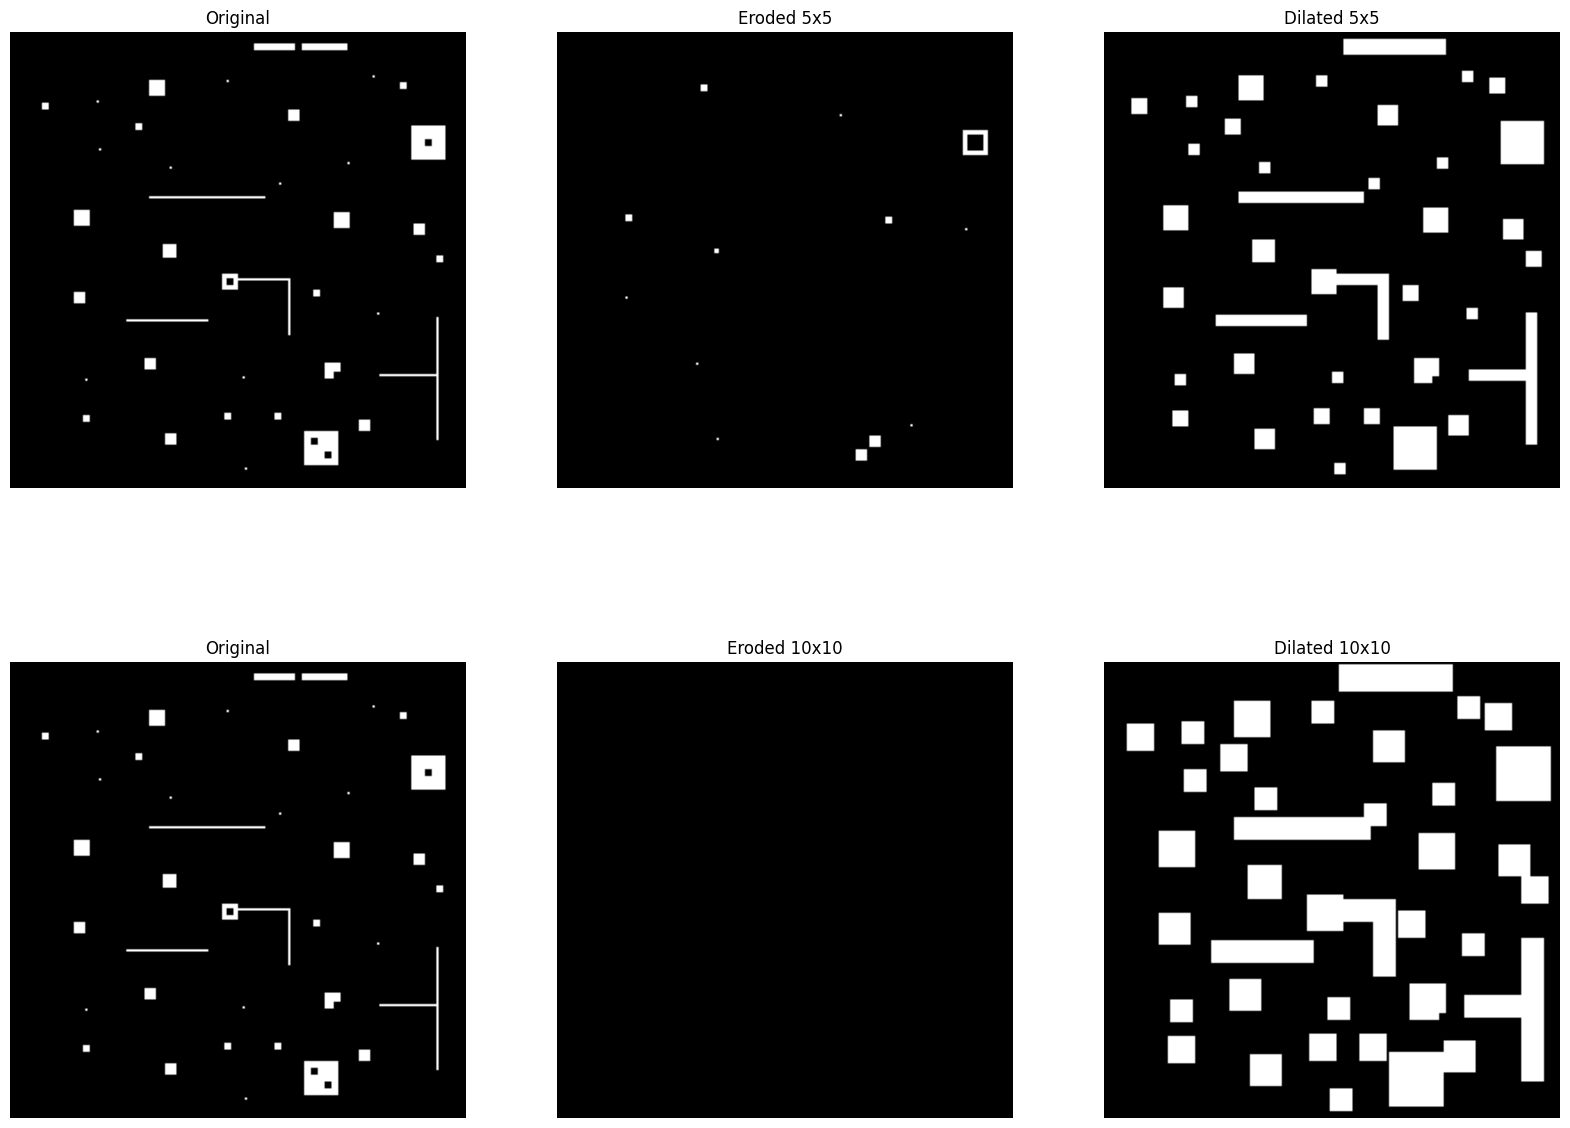

In [17]:
mask = cv2.imread('./images/mask.png')
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(20, 15))

n = 5
SE = np.ones((n,n)) # create a square structuring element
mask_eroded = cv2.erode(mask, SE)
mask_dilated = cv2.dilate(mask, SE)

plt.subplot(2, 3, 1)
plt.imshow(mask, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mask_eroded, cmap='gray')
plt.title('Eroded 5x5')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(mask_dilated, cmap='gray')
plt.title('Dilated 5x5')
plt.axis('off')

n = 10
SE = np.ones((n,n))
mask_eroded = cv2.erode(mask, SE)
mask_dilated = cv2.dilate(mask, SE)

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_eroded, cmap='gray')
plt.title('Eroded 10x10')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(mask_dilated, cmap='gray')
plt.title('Dilated 10x10')
plt.axis('off')


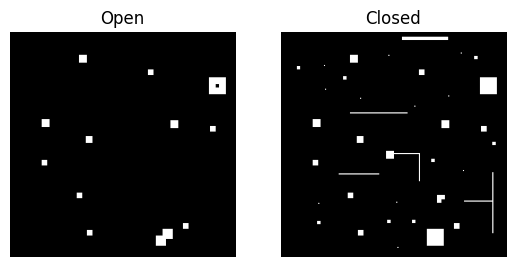

In [18]:
n = 5
SE = np.ones((n,n))

mask_open = cv2.dilate(cv2.erode(mask, SE), SE) # first erosion then dilation
mask_close = cv2.erode(cv2.dilate(mask, SE), SE) # first dilation then erosion

plt.subplot(1, 2, 1)
plt.imshow(mask_open, cmap='gray')
plt.title('Open')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_close, cmap='gray')
plt.title('Closed')
plt.axis('off')
plt.show()

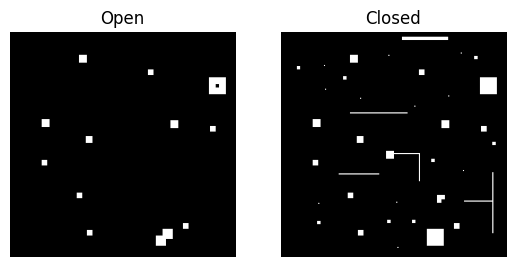

In [19]:
mask_open = cv2.morphologyEx(mask,cv2.MORPH_OPEN,SE) # morphological operators in OpenCv
mask_close = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, SE)

plt.subplot(1, 2, 1)
plt.imshow(mask_open, cmap='gray')
plt.title('Open')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_close, cmap='gray')
plt.title('Closed')
plt.axis('off')
plt.show()

**Question: Based on the results, which order of erosion and dilation operations
produces opening and which closing?**
Opening : erosion and then dilation.
Closing: dilation and then erosion.

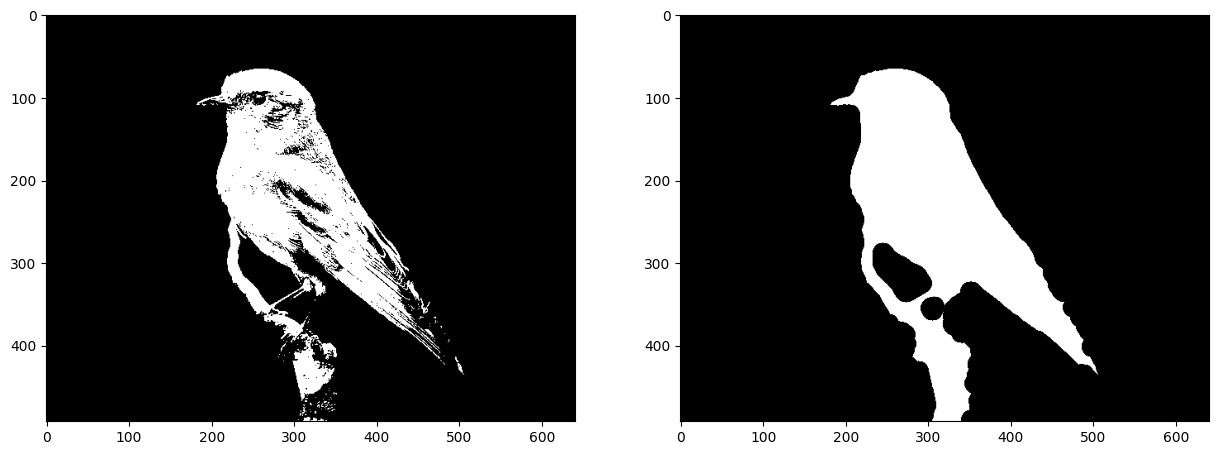

In [20]:
img_clean = bird_otsu.copy()
#print(img_clean.dtype, img_clean.min(), img_clean.max())

plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
img_clean = (img_clean * 255).astype(np.uint8)
plt.imshow(img_clean, cmap='gray')

n = 25
SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(n,n))

plt.subplot(1, 2, 2)
bird_clean = cv2.dilate(img_clean, SE)
bird_clean = cv2.erode(bird_clean, SE)
plt.imshow(bird_clean, cmap='gray')

In [21]:
def immask(I, I_mask):
    I_mask = np.expand_dims(I_mask, 2)
    result_image = np.where(I_mask == 0, [0,0,0], I)
    return result_image

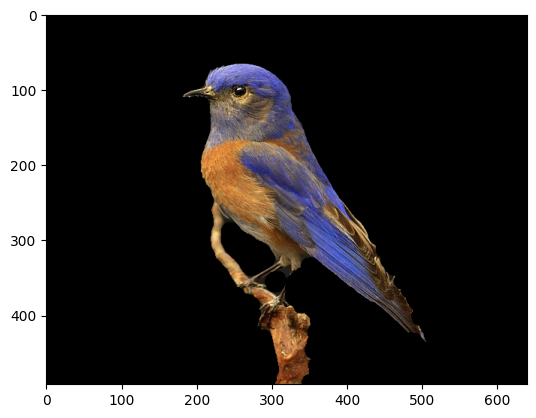

In [22]:
bird_immask = immask(bird, bird_clean)
plt.imshow(bird_immask)
plt.show()


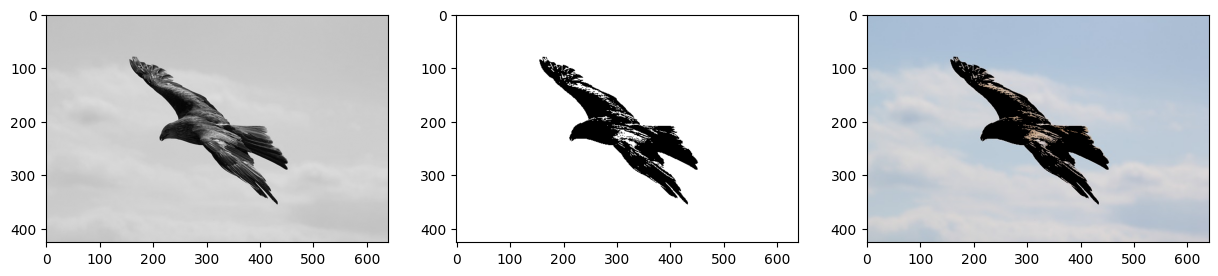

In [29]:
plt.figure(figsize=(15, 10))
eagle = cv2.imread('./images/eagle.jpg')
eagle = cv2.cvtColor(eagle, cv2.COLOR_BGR2RGB)

plt.subplot(1, 3, 1)
eagle_gray = cv2.cvtColor(eagle, cv2.COLOR_BGR2GRAY) / 255
plt.imshow(eagle_gray, cmap='gray')

plt.subplot(1, 3, 2)
eagle_thresh = otsu(eagle_gray)
# print(eagle_thresh)
eagle_mask = otsu_mask(eagle_gray, eagle_thresh)
plt.imshow(eagle_mask, cmap='gray')

plt.subplot(1, 3, 3)
eagle_immask = immask(eagle, eagle_mask)
plt.imshow(eagle_immask)

**Question: Why is the background included in the mask and not the object? How
would you fix that in general? (just inverting the mask if necessary doesn’t count)**
The background is included in the mask because the object is darker than the background so Otsu's method selects pixels that are brighter than the threshold.
In general we could fix that by checking where the histogram has the most frequent intensity. If it's on the bright side - we assume the object is darker, so we keep the pixels below the threshold and if it's on the darker side, we keep the pixels above the threshold.

In [24]:
def otsu_mask_inv(I_gray, threshold):
    otsu_mask = np.where(I_gray < threshold, 1, 0)
    return otsu_mask

In [25]:
def immask_coins(I, I_mask):
    I_mask = np.expand_dims(I_mask, 2)
    result_image = np.where(I_mask == 0, I, [255,255,255])
    return result_image

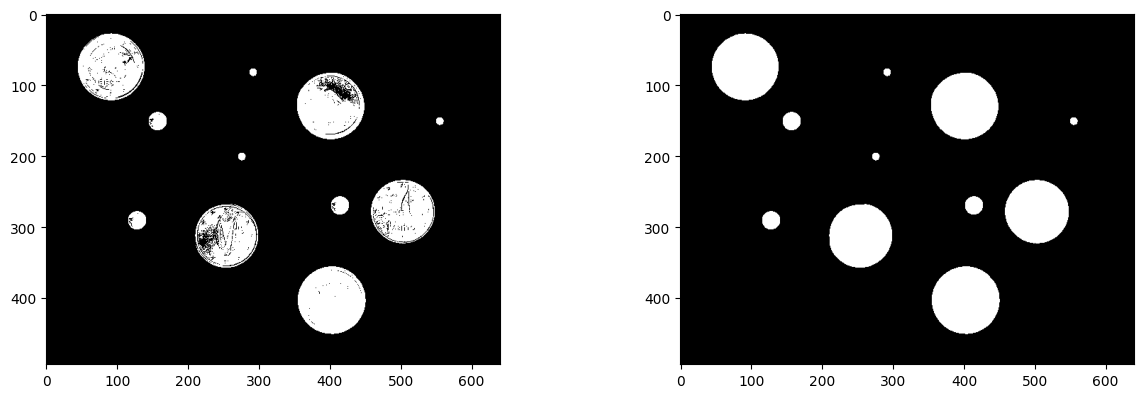

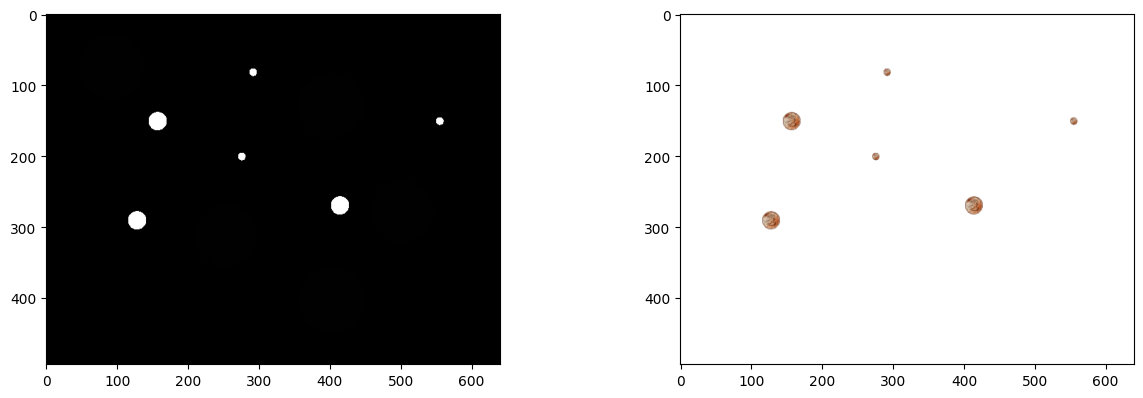

In [26]:
coins = cv2.imread('./images/coins.jpg')
coins = cv2.cvtColor(coins, cv2.COLOR_BGR2RGB)
coins_gray = cv2.cvtColor(coins, cv2.COLOR_RGB2GRAY) / 255
# plt.imshow(img_coins, cmap='gray')
# plt.show()

plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
coins_mask = otsu_mask_inv(coins_gray, otsu(coins_gray))
plt.imshow(coins_mask, cmap='gray')
coins_mask = coins_mask.astype(np.uint8)

n = 15
SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(n,n))
coins_clean = cv2.erode(cv2.dilate(coins_mask, SE), SE)

plt.subplot(2, 2, 2)
plt.imshow(coins_clean, cmap='gray')
plt.show()

filtered_coins = coins_clean.copy()

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(coins_clean)
# print(stats)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    if(area < 700):
        filtered_coins[labels == i] = 255

plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 3)
plt.imshow(filtered_coins, cmap='gray')

filtered_coins_inv = cv2.bitwise_not(filtered_coins)
original_filtered = immask_coins(coins, filtered_coins_inv)
plt.subplot(2, 2, 4)
plt.imshow(original_filtered)
